# How does the merging scenario change things?
---------------------------------------------

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from get_model_probabilities import *
from add_shear_to_data import get_obs_data
import scienceplots
plt.style.use(["science","grid"])
from component_extractor import component_extractor
from scipy.ndimage import zoom

Source redshift:1.36


In [6]:
config='baha2dark'
filter_list  = ['concat']
cdm = 3e-3

ifilter = 'concat'



this_domain = [    {
        'tgt':'darkskies_obs',
    'src':'bahamas_obs'
    },
    {
 
    'tgt':'flamingo_obs',
    'src':'tng_obs'
    }
    
]
fiducial = f"pickles/all_models_{ifilter}_nz_results.pkl"
tng_flamingo = f"pickles/flamingo_tng_results.pkl"

colors = {
    'flamingo':'cyan', 'bahamas':'r', 'darkskies':'b','tng':'green'}

correction=2.1
results = {}

for icomponent in range(0,6):
    results[ icomponent ] = {}
    for ifx, results_file in enumerate( [ fiducial, tng_flamingo ]):
        domain = this_domain[ifx]
        
        
        all_results= pkl.load(open(results_file,'rb'))

        for itgt, target in enumerate(['src','tgt']):
            all_thresholds = []

            domain_name = domain[target].split('_')[0]
            if domain_name == 'tng':
                domain_name = 'tng-cluster'
            for imodel in all_results.keys():

                seed = float(imodel.split('_')[1])                


                tgt = get_threshold_for_cross( 
                    all_results[imodel][target], 
                    dataset=domain[target].split('_')[0],
                    ncomponents=icomponent,
                    quiet=False)


                all_thresholds.append(tgt['thresholds'])

            all_thresholds = np.array(all_thresholds)
            means = np.nanmean(all_thresholds,axis=0)
            errors = np.std(all_thresholds,axis=0) / all_thresholds.shape[0]**0.38*correction

            results[ icomponent ][domain_name] = {'cross':tgt['cross_sections'],'mean':means, 'err':errors}

            
            
fiducial = results[ 1 ]
pkl.dump( [fiducial,results], open("pickles/component_results.pkl","wb"))

In [21]:
fiducial = results[ 1 ]
pkl.dump( [fiducial,results], open("pickles/component_results.pkl","wb"))

In [20]:
fiducial.keys()

dict_keys(['cross', 'mean', 'err'])

In [18]:
fiducial = results[ 1 ][domain_name]


In [ ]:
tgt = get_threshold_for_cross( 
                    all_results[imodel][target], 
                    dataset=domain[target].split('_')[0],
                    ncomponents=0,
                    quiet=False)


In [17]:
fiducial.keys()

dict_keys(['cross', 'mean', 'err'])

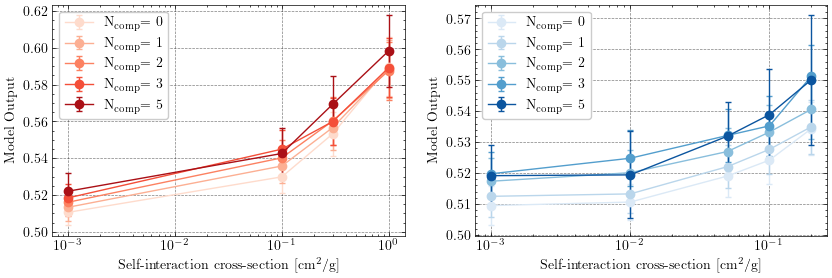

In [9]:
fid, results = pkl.load(open("pickles/component_results.pkl","rb"))
fig, ax = plt.subplots(1,2, figsize=(10,3))


colors = {"bahamas":colourFromRange([-1,len(results.keys())], cmap='Reds'),
          "darkskies":colourFromRange([-1,len(results.keys())], cmap='Blues')
         }



for icx, icomp in enumerate(results.keys()):
    if icx == 4:
        continue
    for idx, idomain in enumerate(results[icomp].keys()):
        if idx >1:
            continue
        results[icomp][idomain]['cross'][0] = 1e-3
        ax[idx].errorbar(
                results[icomp][idomain]['cross'],
                1-results[icomp][idomain]['mean'],
                results[icomp][idomain]['err'],fmt='-o',capsize=2,
            label=f"N$_{{\\rm comp}}$= {icomp}",
        color=colors[idomain][icx])
        ax[idx].set_xscale('log')
        ax[idx].legend()
        ax[idx].set_xlabel("Self-interaction cross-section [cm$^2$/g]")
        ax[idx].set_ylabel("Model Output")


# Individual files

# Run sextractor on all convergence fields and save the outputs

In [97]:
all_shears = glob("../data/100/convergence/bahamas*.pkl") + glob("../data/100/convergence/darkskies*.pkl")
zoomed_amount= 2

for ishear in all_shears:
    if len(ishear.split('_')) == 3:
        continue
    print(ishear)

            
    m,all_halos=pkl.load(open(ishear,"rb"))
    
    
    all_components  = []
    for ihalo in tqdm(all_halos):

        extracted_components = component_extractor( 
                    zoom(ihalo[0,:,:],zoomed_amount),
                    use_sex=True,
                )
        extracted_components['X_IMAGE'] /= zoomed_amount
        extracted_components['Y_IMAGE'] /= zoomed_amount
        
        all_components.append(extracted_components)
    pkl.dump(all_components, open(f"pickles/{ishear.split('/')[-1]}.comps","wb"))

../data/100/convergence/bahamas_0.3.pkl


100%|███████████████████████████████████████| 3600/3600 [04:04<00:00, 14.72it/s]


../data/100/convergence/bahamas_0.1.pkl


100%|███████████████████████████████████████| 3600/3600 [04:05<00:00, 14.66it/s]


../data/100/convergence/bahamas_cdm.pkl


100%|███████████████████████████████████████| 3600/3600 [04:10<00:00, 14.39it/s]


../data/100/convergence/bahamas_1.pkl


100%|███████████████████████████████████████| 3600/3600 [04:07<00:00, 14.52it/s]


# Add ncomponents to each shear file to be used in the inference

In [98]:
all_shears = glob("../data/100/convergence/bahamas*.pkl") + glob("../data/100/convergence/darkskies*.pkl")

zoomed_amount= 2
mass_ratio_limit = 10


for ishear in all_shears:
    if len(ishear.split('_')) == 3:
        continue
    print(ishear)

    extracted_components = pkl.load(open(f"pickles/{ishear.split('/')[-1]}.comps","rb"))
    ncomponents = []
    for icomp in extracted_components:
        mass_ratio = icomp['FLUX_AUTO'].max() / icomp['FLUX_AUTO']
        
        icomp = icomp[ mass_ratio < mass_ratio_limit ]
        ncomponents.append( icomp.shape[0])
        
    newname = ishear.replace('convergence','shear')
    if not os.path.isfile(newname):
        continue
    if newname == ishear:
        raise ValueError("Wrong")
    m, obs = pkl.load(open(newname,'rb'))
    m['ncomponents'] = np.array(ncomponents)
    pkl.dump([m,obs],open(newname,'wb'))
    

../data/100/convergence/bahamas_0.3.pkl
../data/100/convergence/bahamas_0.1.pkl
../data/100/convergence/bahamas_cdm.pkl
../data/100/convergence/bahamas_1.pkl
../data/100/convergence/darkskies_0.01.pkl
../data/100/convergence/darkskies_cdm.pkl
../data/100/convergence/darkskies_0.05.pkl
../data/100/convergence/darkskies_0.2.pkl
../data/100/convergence/darkskies_0.1.pkl
